# VIPER Model — VUS Reclassification

**Pipeline stage:** 5 of 6  
**Inputs:** `rf_model_tuned.pkl`, `feature_cols.pkl`, `clinvar_features_engineered.tsv`, `clinvar_vep_cadd_final.tsv`, `clinvar_result.xlsx`  
**Outputs:** `vus_reclassification_results.csv`, figures `vus_01_` → `vus_05_`, `figure_sensitivity_analysis.png`, `figure_disease_categories.png`  

---

## Contents
1. [Imports & Load Artefacts](#1-imports--load-artefacts)
2. [VUS Extraction & Prediction](#2-vus-extraction--prediction)
3. [Threshold Sensitivity Analysis](#3-threshold-sensitivity-analysis)
4. [Feature Profile Comparison](#4-feature-profile-comparison)
5. [Gene & Consequence Analysis](#5-gene--consequence-analysis)
6. [Disease Condition Enrichment](#6-disease-condition-enrichment)
   - 6.1 Merge condition metadata
   - 6.2 Hereditary cancer gene analysis
   - 6.3 Disease category classification
7. [Visualisation Suite](#7-visualisation-suite)
   - Plot 1: Reclassification summary (bar + pie)
   - Plot 2: Probability distribution
   - Plot 3: CADD PHRED distribution
   - Plot 4: Top 10 genes
   - Plot 5: Consequence distribution
   - Figure: Sensitivity analysis
   - Figure: Disease category breakdown
8. [Export Results](#8-export-results)


## 1. Imports & Load Artefacts

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

COLORS = {
    'Reclassified_Pathogenic': '#D7191C',
    'Reclassified_Benign':     '#2C7BB6',
    'Remains_VUS':             '#FDAE61'
}

with open('rf_model_tuned.pkl', 'rb') as f:
    rf_best = pickle.load(f)

with open('feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

df = pd.read_csv('clinvar_features_engineered.tsv', sep='\t', low_memory=False)

print(f'Model loaded: {rf_best}')
print(f'Dataset shape: {df.shape}')
print(f'Feature cols: {feature_cols}')

Model loaded: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)
Dataset shape: (104639, 25)
Feature cols: ['PHRED', 'MAX_AF', 'PolyPhen_score', 'IMPACT_encoded', 'VARIANT_CLASS_encoded', 'BIOTYPE_encoded', 'SIFT_cat_encoded', 'PolyPhen_cat_encoded', 'Consequence_grouped_encoded']


## 2. VUS Extraction & Prediction

Apply the three-zone classifier (trained thresholds: Pathogenic ≥ 0.80, Benign <= 0.20)  
to all VUS variants held out from model training.


In [2]:
patho_terms = [
    'Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic',
    'Pathogenic; drug response', 'Pathogenic/Likely pathogenic; risk factor',
    'Pathogenic/Likely pathogenic; other', 'Pathogenic/Likely pathogenic; association',
    'Pathogenic/Pathogenic, low penetrance; other',
    'Likely pathogenic; association',
    'Pathogenic/Likely pathogenic/Pathogenic, low penetrance'
]
benign_terms = [
    'Benign', 'Likely benign', 'Benign/Likely benign',
    'Benign; drug response', 'Benign/Likely benign; other',
    'Benign/Likely benign; association', 'Benign; association',
    'Likely benign; drug response; other', 'Likely benign; other',
    'Likely benign; association'
]

def group_label(x):
    if x in patho_terms:    return 'Pathogenic'
    elif x in benign_terms: return 'Benign'
    else:                   return 'VUS'

df['label_group'] = df['Germline classification'].apply(group_label)
vus_df = df[df['label_group'] == 'VUS'].copy()

print(f'Total VUS variants: {len(vus_df):,}')
print(f'\nRaw ClinVar VUS classifications:')
print(vus_df['Germline classification'].value_counts())

Total VUS variants: 40,894

Raw ClinVar VUS classifications:
Germline classification
Uncertain significance                          40887
Uncertain significance/Uncertain risk allele        6
Uncertain significance; drug response               1
Name: count, dtype: int64


In [3]:
# Predict probabilities
X_vus    = vus_df[feature_cols]
vus_prob = rf_best.predict_proba(X_vus)[:, 1]

# Three-zone thresholds (adopted from PR curve analysis in notebook 03)
PATHO_THRESHOLD  = 0.80
BENIGN_THRESHOLD = 0.20

def classify_variant(prob):
    if prob >= PATHO_THRESHOLD:   return 'Reclassified_Pathogenic'
    elif prob <= BENIGN_THRESHOLD: return 'Reclassified_Benign'
    else:                         return 'Remains_VUS'

vus_df['rf_prob']         = vus_prob
vus_df['predicted_class'] = [classify_variant(p) for p in vus_prob]

print('=== VUS Reclassification Results ===')
counts = vus_df['predicted_class'].value_counts()
for cls, n in counts.items():
    print(f'  {cls}: {n:,} ({n/len(vus_df)*100:.1f}%)')

=== VUS Reclassification Results ===
  Reclassified_Pathogenic: 19,393 (47.4%)
  Remains_VUS: 12,544 (30.7%)
  Reclassified_Benign: 8,957 (21.9%)


## 3. Threshold Sensitivity Analysis

Examine how reclassification counts shift across four candidate Pathogenic thresholds  
(Benign threshold fixed at 0.20).  
`→ saves: figure_sensitivity_analysis.png`


In [5]:
print('Threshold sensitivity (Benign threshold fixed at 0.20):')
for t in [0.70, 0.80, 0.90, 0.95]:
    n_patho  = (vus_prob >= t).sum()
    n_benign = (vus_prob <= 0.20).sum()
    n_vus    = len(vus_prob) - n_patho - n_benign
    adopted  = ' ← adopted' if t == 0.80 else ''
    print(f'  Threshold {t}: Pathogenic={n_patho:,} ({n_patho/len(vus_prob)*100:.1f}%) | '
          f'Benign={n_benign:,} ({n_benign/len(vus_prob)*100:.1f}%) | '
          f'VUS={n_vus:,} ({n_vus/len(vus_prob)*100:.1f}%){adopted}')

Threshold sensitivity (Benign threshold fixed at 0.20):
  Threshold 0.7: Pathogenic=22,012 (53.8%) | Benign=8,957 (21.9%) | VUS=9,925 (24.3%)
  Threshold 0.8: Pathogenic=19,393 (47.4%) | Benign=8,957 (21.9%) | VUS=12,544 (30.7%) ← adopted
  Threshold 0.9: Pathogenic=14,807 (36.2%) | Benign=8,957 (21.9%) | VUS=17,130 (41.9%)
  Threshold 0.95: Pathogenic=11,201 (27.4%) | Benign=8,957 (21.9%) | VUS=20,736 (50.7%)


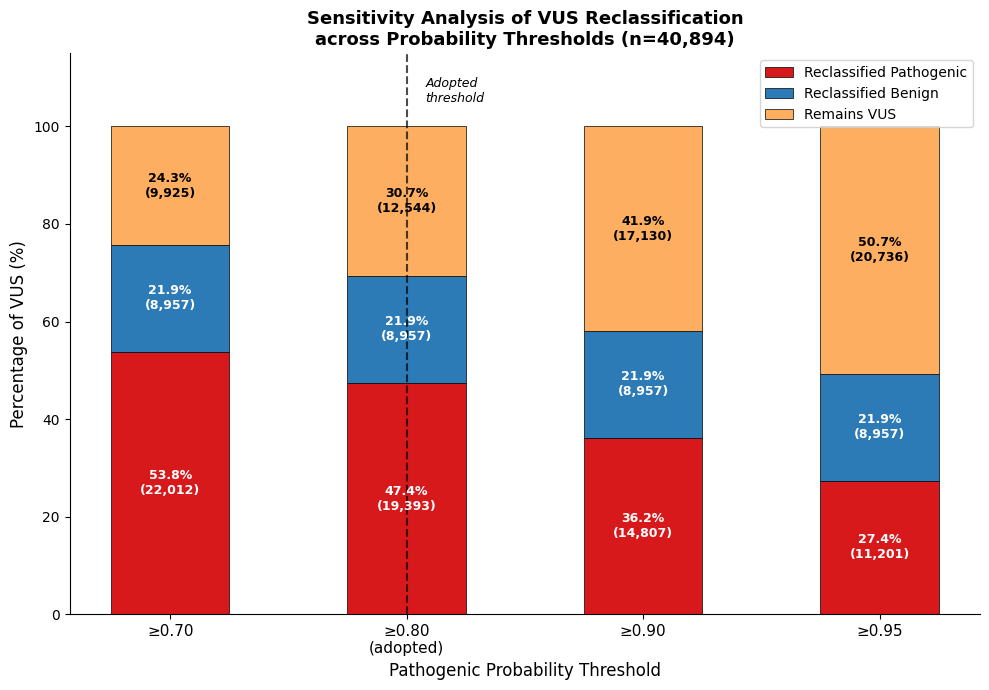

Saved: figure_sensitivity_analysis.png


In [6]:
# Hardcoded from sensitivity scan above (update if thresholds change)
thresholds   = ['\u22650.70', '\u22650.80\n(adopted)', '\u22650.90', '\u22650.95']
n_pathogenic = [22012, 19393, 14807, 11201]
n_benign     = [8957,  8957,  8957,  8957]
n_remains    = [9925,  12544, 17130, 20736]
total        = 40894

patho_pct  = [p/total*100 for p in n_pathogenic]
benign_pct = [b/total*100 for b in n_benign]
vus_pct    = [v/total*100 for v in n_remains]
x          = range(len(thresholds))

fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.bar(x, patho_pct, 0.5,
               label='Reclassified Pathogenic', color='#D7191C',
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, benign_pct, 0.5, bottom=patho_pct,
               label='Reclassified Benign', color='#2C7BB6',
               edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x, vus_pct, 0.5,
               bottom=[p+b for p,b in zip(patho_pct, benign_pct)],
               label='Remains VUS', color='#FDAE61',
               edgecolor='black', linewidth=0.5)

for i, (p, b, v) in enumerate(zip(patho_pct, benign_pct, vus_pct)):
    ax.text(i, p/2,       f'{p:.1f}%\n({n_pathogenic[i]:,})',
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax.text(i, p + b/2,   f'{b:.1f}%\n({n_benign[i]:,})',
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax.text(i, p + b + v/2, f'{v:.1f}%\n({n_remains[i]:,})',
            ha='center', va='center', fontsize=9, fontweight='bold', color='black')

# Highlight adopted threshold
ax.axvline(x=1, color='black', linestyle='--', lw=1.5, alpha=0.7)
ax.text(1.08, 105, 'Adopted\nthreshold', ha='left', fontsize=9, style='italic')

ax.set_xticks(list(x))
ax.set_xticklabels(thresholds, fontsize=11)
ax.set_xlabel('Pathogenic Probability Threshold', fontsize=12)
ax.set_ylabel('Percentage of VUS (%)', fontsize=12)
ax.set_title('Sensitivity Analysis of VUS Reclassification\nacross Probability Thresholds (n=40,894)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_sensitivity_analysis.png')

## 4. Feature Profile Comparison

Descriptive statistics for key continuous features across the three reclassification groups.


In [7]:
patho_vus   = vus_df[vus_df['predicted_class'] == 'Reclassified_Pathogenic'].copy()
benign_vus  = vus_df[vus_df['predicted_class'] == 'Reclassified_Benign'].copy()
remains_vus = vus_df[vus_df['predicted_class'] == 'Remains_VUS'].copy()

key_features = ['PHRED', 'MAX_AF', 'PolyPhen_score']

for group, subset in [('Reclassified Pathogenic', patho_vus),
                       ('Reclassified Benign',     benign_vus),
                       ('Remains VUS',             remains_vus)]:
    print(f'\n=== {group} (n={len(subset):,}) ===')
    print(subset[key_features].describe().round(3))

print('\n=== Mean probability by group ===')
for group, subset in [('Reclassified Pathogenic', patho_vus),
                       ('Reclassified Benign',     benign_vus),
                       ('Remains VUS',             remains_vus)]:
    print(f'  {group}: {subset["rf_prob"].mean():.3f}')


=== Reclassified Pathogenic (n=19,393) ===
           PHRED     MAX_AF  PolyPhen_score
count  19393.000  19393.000       19393.000
mean      26.163      0.000           0.367
std        3.395      0.000           0.783
min        0.012      0.000          -1.000
25%       24.000      0.000           0.033
50%       25.600      0.000           0.796
75%       27.800      0.000           0.991
max       64.000      0.005           1.000

=== Reclassified Benign (n=8,957) ===
          PHRED    MAX_AF  PolyPhen_score
count  8957.000  8957.000        8957.000
mean     12.069     0.001          -0.175
std       6.758     0.016           0.490
min       0.001     0.000          -1.000
25%       7.011     0.000           0.000
50%      12.900     0.000           0.003
75%      16.890     0.000           0.041
max      33.000     1.000           1.000

=== Remains VUS (n=12,544) ===
           PHRED     MAX_AF  PolyPhen_score
count  12544.000  12544.000       12544.000
mean      21.144      0

## 5. Gene & Consequence Analysis

Identify top genes and consequence types enriched in each reclassification group.  
Gene symbols resolved from `clinvar_vep_cadd_final.tsv` (SYMBOL column).


In [8]:
consequence_map = {
    0:'UTR', 1:'canonical_splice', 2:'frameshift', 3:'inframe_indel',
    4:'intronic', 5:'missense', 6:'other', 7:'regulatory',
    8:'splice_region', 9:'stop_variant', 10:'synonymous'
}

for subset in [patho_vus, benign_vus, remains_vus]:
    subset['Consequence_label'] = subset['Consequence_grouped_encoded'].map(consequence_map)

for group, subset in [('Reclassified Pathogenic', patho_vus),
                       ('Reclassified Benign',     benign_vus)]:
    print(f'\nTop 10 Consequences — {group}:')
    print(subset['Consequence_label'].value_counts().head(10))


Top 10 Consequences — Reclassified Pathogenic:
Consequence_label
missense            15413
regulatory           1521
splice_region         944
canonical_splice      565
inframe_indel         428
frameshift            239
stop_variant          207
other                  60
intronic               11
UTR                     5
Name: count, dtype: int64

Top 10 Consequences — Reclassified Benign:
Consequence_label
missense            7156
regulatory           844
canonical_splice     399
splice_region        397
UTR                   65
synonymous            47
intronic              43
inframe_indel          5
other                  1
Name: count, dtype: int64


In [10]:
# Load original dataset for SYMBOL column
df_orig = pd.read_csv('/home/nayeema/Sysgen/VUS/clinvar_vep_cadd_final.tsv', sep='\t', low_memory=False)
gene_symbol_map = df_orig[['Gene', 'SYMBOL']].drop_duplicates()
print(f'Gene-Symbol pairs: {len(gene_symbol_map):,}')

# Add symbols to VUS dataframe
vus_df = vus_df.merge(gene_symbol_map, on='Gene', how='left')
patho_vus  = vus_df[vus_df['predicted_class'] == 'Reclassified_Pathogenic'].copy()
benign_vus = vus_df[vus_df['predicted_class'] == 'Reclassified_Benign'].copy()

for group, subset, color in [('Reclassified Pathogenic', patho_vus,  'red'),
                               ('Reclassified Benign',     benign_vus, 'blue')]:
    print(f'\nTop 10 Genes — {group}:')
    print(subset['SYMBOL'].value_counts().head(10))

Gene-Symbol pairs: 3,159

Top 10 Genes — Reclassified Pathogenic:
SYMBOL
APC      1950
ATM      1310
MSH6      789
BRIP1     716
CHEK2     646
TSC2      618
NF1       559
BRCA2     522
BARD1     487
PMS2      440
Name: count, dtype: int64

Top 10 Genes — Reclassified Benign:
SYMBOL
APC      642
PALB2    500
ATM      413
BRIP1    344
BRCA2    282
BARD1    269
MSH6     251
BLM      246
BRCA1    240
MSH3     218
Name: count, dtype: int64


## 6. Disease Condition Enrichment

### 6.1 Merge Condition Metadata

In [16]:
vus_results = pd.read_csv('/home/nayeema/Sysgen/VUS/vus_reclassification_results.csv')

clinvar_excel = pd.read_excel('/home/nayeema/Sysgen/VUS/clinvar_result.xlsx',
                               usecols=['VariationID', 'Condition(s)',
                                        'Gene(s)', 'Germline classification'])
print(f'Excel shape: {clinvar_excel.shape}')
print(f'\nSample conditions:')
print(clinvar_excel['Condition(s)'].value_counts().head(10))

vus_results['ID']                    = vus_results['ID'].astype(str)
clinvar_excel['VariationID']         = clinvar_excel['VariationID'].astype(str)

vus_conditions = vus_results.merge(
    clinvar_excel[['VariationID', 'Condition(s)']],
    left_on='ID', right_on='VariationID', how='left'
)
vus_conditions['primary_condition'] = (
    vus_conditions['Condition(s)'].str.split('|').str[0].str.strip()
)

print(f'\nVUS with conditions: {len(vus_conditions):,}')
print(f'Missing conditions:  {vus_conditions["Condition(s)"].isna().sum():,}')

/tmp/ipykernel_510/3740011663.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  vus_results = pd.read_csv('/home/nayeema/Sysgen/VUS/vus_reclassification_results.csv')


Excel shape: (104653, 4)

Sample conditions:
Condition(s)
Breast-ovarian cancer, familial, susceptibility to, 2                                   4090
Breast-ovarian cancer, familial, susceptibility to, 1                                   3317
Hereditary cancer-predisposing syndrome|Familial cancer of breast                       3130
Hereditary cancer-predisposing syndrome|not provided                                    2993
Hereditary cancer-predisposing syndrome|Familial adenomatous polyposis 1                2516
not provided                                                                            2296
Hereditary cancer-predisposing syndrome                                                 1635
Hereditary cancer-predisposing syndrome|Hereditary breast ovarian cancer syndrome       1597
not provided|Hereditary cancer-predisposing syndrome                                    1549
Hereditary nonpolyposis colorectal neoplasms|Hereditary cancer-predisposing syndrome    1278
Name: count,

### 6.2 Hereditary Cancer Gene Analysis

In [17]:
hereditary_cancer_genes = [
    'BRCA1', 'BRCA2', 'PALB2', 'BRIP1', 'RAD51C', 'RAD51D',
    'MLH1', 'MSH2', 'MSH6', 'PMS2', 'EPCAM',
    'APC', 'MUTYH', 'CHEK2', 'ATM', 'BARD1',
    'TP53', 'PTEN', 'STK11', 'CDH1', 'VHL',
    'MEN1', 'RET', 'NF1', 'NF2', 'TSC1', 'TSC2',
    'BMPR1A', 'SMAD4', 'NBN', 'FANCM',
    'MSH3', 'BLM', 'RECQL'
]

vus_cancer     = vus_conditions[vus_conditions['SYMBOL'].isin(hereditary_cancer_genes)]
vus_non_cancer = vus_conditions[~vus_conditions['SYMBOL'].isin(hereditary_cancer_genes)]

print(f'Total VUS:                          {len(vus_conditions):,}')
print(f'In hereditary cancer genes:         {len(vus_cancer):,} ({len(vus_cancer)/len(vus_conditions)*100:.1f}%)')
print(f'In other genes:                     {len(vus_non_cancer):,} ({len(vus_non_cancer)/len(vus_conditions)*100:.1f}%)')
print(f'\nReclassification in cancer genes:')
print(vus_cancer['predicted_class'].value_counts())
print(f'\nTop 15 hereditary cancer genes with VUS:')
print(vus_cancer['SYMBOL'].value_counts().head(15))

Total VUS:                          40,894
In hereditary cancer genes:         24,539 (60.0%)
In other genes:                     16,355 (40.0%)

Reclassification in cancer genes:
predicted_class
Reclassified_Pathogenic    12107
Remains_VUS                 7361
Reclassified_Benign         5071
Name: count, dtype: int64

Top 15 hereditary cancer genes with VUS:
SYMBOL
APC      3889
ATM      2581
MSH6     1427
BRIP1    1413
PALB2    1256
BRCA2    1169
CHEK2    1055
BARD1    1038
TSC2     1016
NF1       949
PMS2      857
MSH3      829
BRCA1     801
BLM       684
CDH1      662
Name: count, dtype: int64


### 6.3 Disease Category Classification

In [18]:
def categorize_condition(condition):
    c = str(condition).lower()
    if any(t in c for t in [
            'cancer', 'carcinoma', 'tumor', 'tumour', 'neoplasm',
            'polyposis', 'lynch', 'brca', 'melanoma', 'leukemia',
            'lymphoma', 'blastoma', 'sarcoma', 'glioma', 'meningioma',
            'hereditary cancer', 'cancer predispos', 'predisposition',
            'ovarian', 'breast', 'colorectal', 'adenomatous',
            'paraganglioma', 'pheochromocytoma', 'retinoblastoma',
            'wilms', 'ependymoma', 'medulloblastoma']):
        return 'Hereditary Cancer'
    elif any(t in c for t in [
            'cardiac', 'cardiomyopathy', 'arrhythmia', 'aortic',
            'cardiovascular', 'long qt', 'brugada', 'atrial',
            'ventricular', 'hypertrophic cardiomyopathy']):
        return 'Cardiovascular'
    elif any(t in c for t in [
            'neuro', 'epilep', 'encephalop', 'ataxia', 'paraplegia',
            'dementia', 'amyotrophic', 'cerebell', 'intellectual disability',
            'developmental delay', 'autism', 'neuropathy']):
        return 'Neurological'
    elif any(t in c for t in [
            'immunodeficiency', 'immune', 'autoimmune', 'lupus',
            'inflammatory', 'fanconi anemia', 'aplastic anemia']):
        return 'Immunological/Blood'
    elif any(t in c for t in [
            'metabolic', 'diabetes', 'cholesterol', 'lipid',
            'aciduria', 'acidemia', 'glycogen', 'mitochondrial',
            'fatty acid', 'amino acid']):
        return 'Metabolic'
    elif any(t in c for t in [
            'marfan', 'ehlers', 'skeletal', 'osteogenesis',
            'dysplasia', 'arthrogryposis', 'myopathy', 'muscular dystrophy']):
        return 'Connective Tissue/Skeletal'
    elif any(t in c for t in ['not provided', 'not specified', 'inborn genetic']):
        return 'Not Specified'
    else:
        return 'Other'

vus_conditions['disease_category'] = (
    vus_conditions['primary_condition'].apply(categorize_condition)
)

print('=== Disease Category Distribution — All VUS ===')
print(vus_conditions['disease_category'].value_counts())
print('\n=== Cross-tabulation by Reclassification Group ===')
print(pd.crosstab(vus_conditions['disease_category'],
                  vus_conditions['predicted_class'], margins=True))

=== Disease Category Distribution — All VUS ===
disease_category
Hereditary Cancer             30559
Not Specified                  5130
Other                          2507
Neurological                   1101
Cardiovascular                  768
Immunological/Blood             569
Metabolic                       163
Connective Tissue/Skeletal       97
Name: count, dtype: int64

=== Cross-tabulation by Reclassification Group ===
predicted_class             Reclassified_Benign  Reclassified_Pathogenic  \
disease_category                                                           
Cardiovascular                               83                      400   
Connective Tissue/Skeletal                   19                       47   
Hereditary Cancer                          6377                    14952   
Immunological/Blood                         155                      249   
Metabolic                                    44                       68   
Neurological                         

## 7. Visualisation Suite

### Plot 1: Reclassification Summary  
`→ saves: vus_01_reclassification_summary.png`

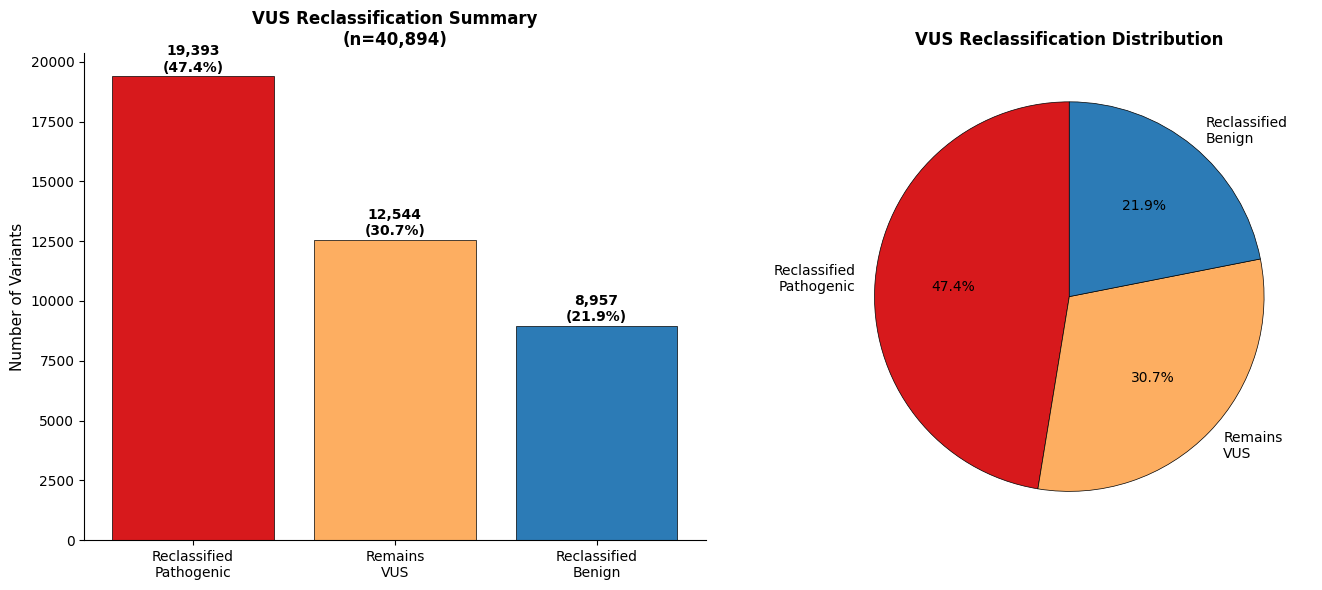

Saved: vus_01_reclassification_summary.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = vus_df['predicted_class'].value_counts()
counts = counts.reindex(['Reclassified_Pathogenic', 'Remains_VUS', 'Reclassified_Benign'])
labels = ['Reclassified\nPathogenic', 'Remains\nVUS', 'Reclassified\nBenign']

bars = axes[0].bar(labels, counts.values,
                   color=[COLORS[c] for c in counts.index],
                   edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/len(vus_df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('VUS Reclassification Summary\n(n=40,894)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Variants', fontsize=11)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].pie(counts.values, labels=labels,
            colors=[COLORS[c] for c in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('VUS Reclassification Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('vus_01_reclassification_summary.png', dpi=150)
plt.show()
print('Saved: vus_01_reclassification_summary.png')

### Plot 2: Probability Distribution  
`→ saves: vus_02_probability_distribution.png`

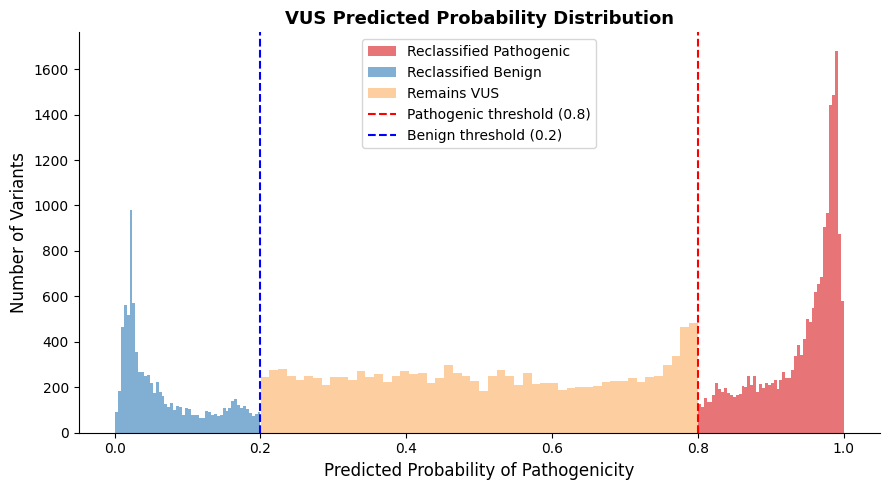

Saved: vus_02_probability_distribution.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
for group, color in COLORS.items():
    subset = vus_df[vus_df['predicted_class'] == group]['rf_prob']
    ax.hist(subset, bins=50, alpha=0.6, color=color,
            label=group.replace('_', ' '), edgecolor='none')
ax.axvline(x=PATHO_THRESHOLD,  color='red',  linestyle='--', lw=1.5,
           label=f'Pathogenic threshold ({PATHO_THRESHOLD})')
ax.axvline(x=BENIGN_THRESHOLD, color='blue', linestyle='--', lw=1.5,
           label=f'Benign threshold ({BENIGN_THRESHOLD})')
ax.set_xlabel('Predicted Probability of Pathogenicity', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('VUS Predicted Probability Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('vus_02_probability_distribution.png', dpi=150)
plt.show()
print('Saved: vus_02_probability_distribution.png')

### Plot 3: CADD PHRED Distribution  
`→ saves: vus_03_phred_distribution.png`

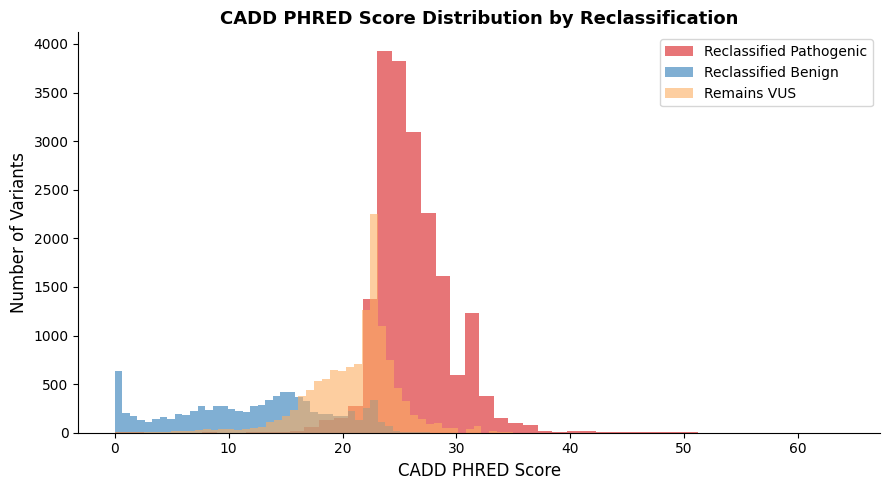

Saved: vus_03_phred_distribution.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
for group, color in COLORS.items():
    subset = vus_df[vus_df['predicted_class'] == group]['PHRED']
    ax.hist(subset, bins=50, alpha=0.6, color=color,
            label=group.replace('_', ' '), edgecolor='none')
ax.set_xlabel('CADD PHRED Score', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('CADD PHRED Score Distribution by Reclassification',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('vus_03_phred_distribution.png', dpi=150)
plt.show()
print('Saved: vus_03_phred_distribution.png')

### Plot 4: Top 10 Genes  
`→ saves: vus_04_top_genes.png`

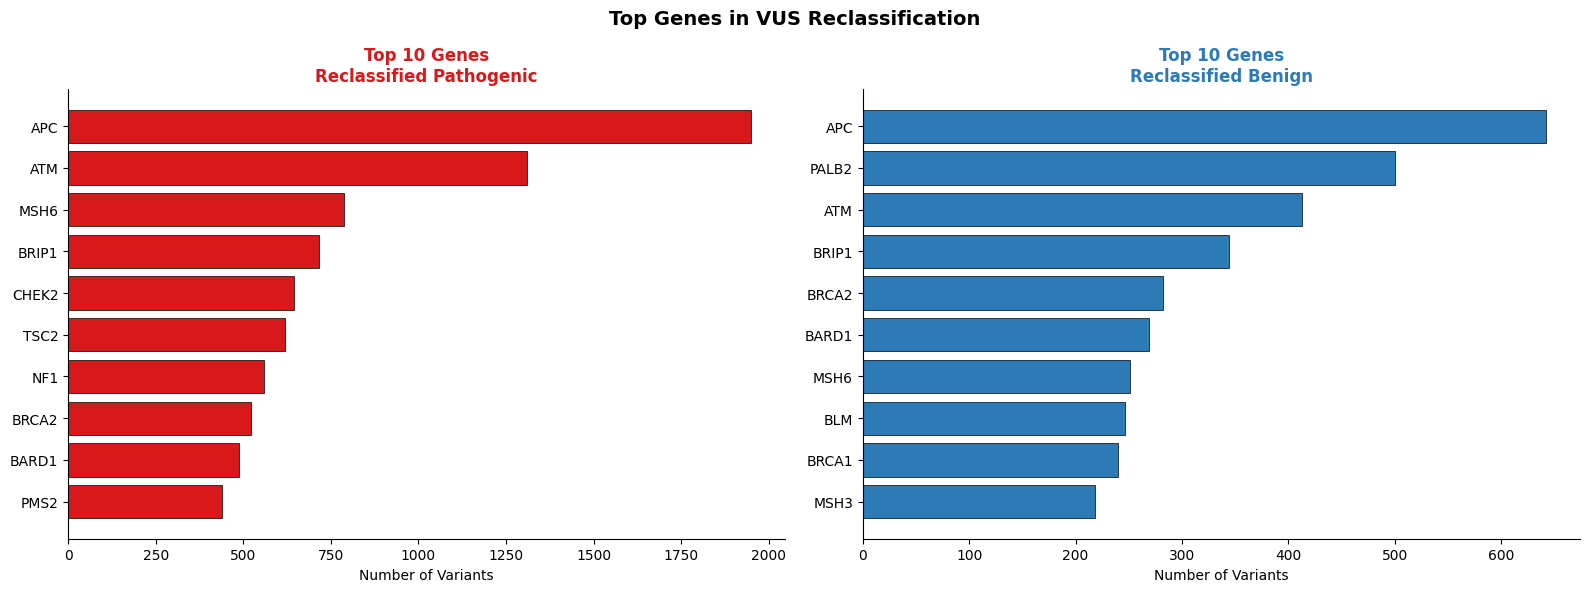

Saved: vus_04_top_genes.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, subset, title, color in [
    (axes[0], patho_vus,  'Reclassified Pathogenic', '#D7191C'),
    (axes[1], benign_vus, 'Reclassified Benign',     '#2C7BB6')
]:
    top = subset['SYMBOL'].value_counts().head(10)
    ax.barh(top.index[::-1], top.values[::-1],
            color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top 10 Genes\n{title}', fontsize=12,
                 fontweight='bold', color=color)
    ax.set_xlabel('Number of Variants', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Top Genes in VUS Reclassification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vus_04_top_genes.png', dpi=150)
plt.show()
print('Saved: vus_04_top_genes.png')

### Plot 5: Consequence Distribution  
`→ saves: vus_05_consequence_distribution.png`

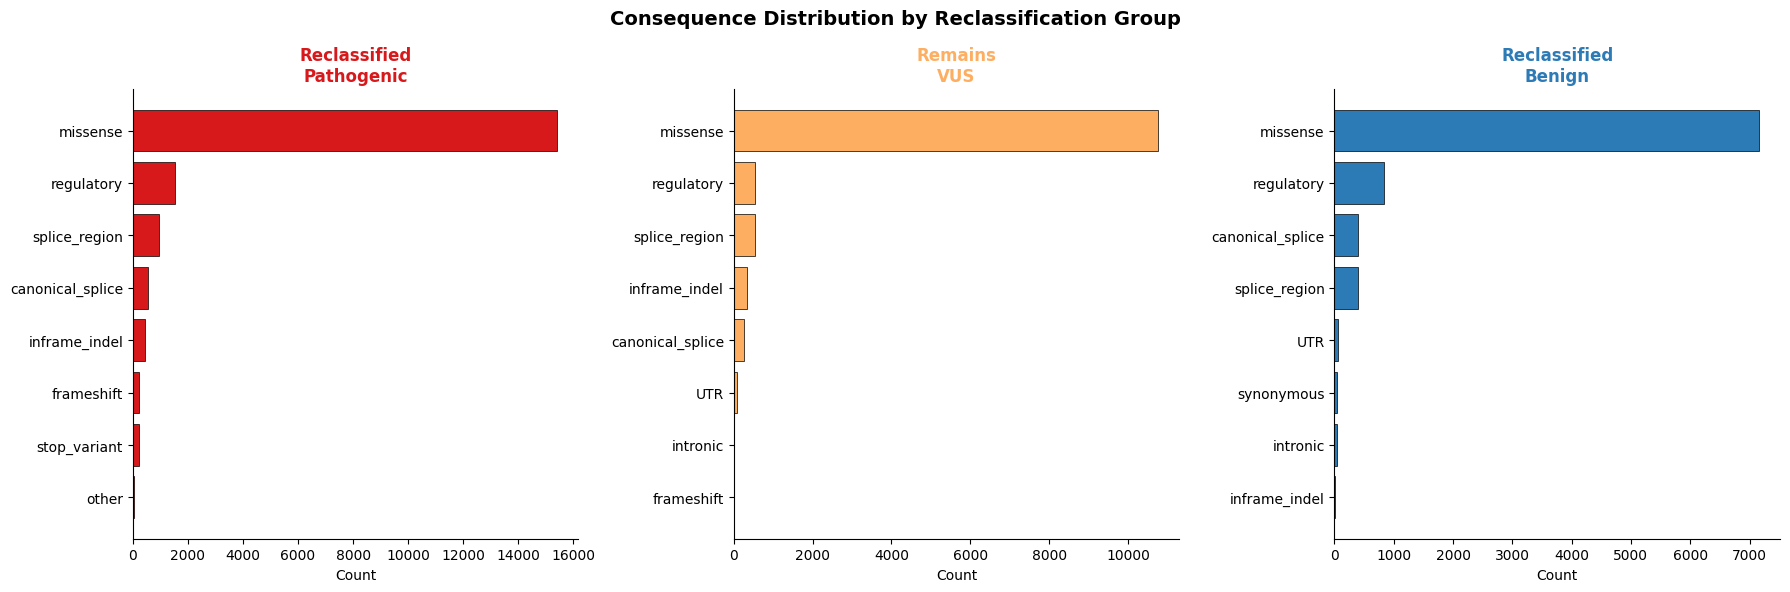

Saved: vus_05_consequence_distribution.png


In [24]:
# Add Consequence_label to all three groups
consequence_map = {0:'UTR', 1:'canonical_splice', 2:'frameshift',
                   3:'inframe_indel', 4:'intronic', 5:'missense',
                   6:'other', 7:'regulatory', 8:'splice_region',
                   9:'stop_variant', 10:'synonymous'}

patho_vus = patho_vus.copy()
benign_vus = benign_vus.copy()
remains_vus = remains_vus.copy()

patho_vus['Consequence_label'] = patho_vus['Consequence_grouped_encoded'].map(consequence_map)
benign_vus['Consequence_label'] = benign_vus['Consequence_grouped_encoded'].map(consequence_map)
remains_vus['Consequence_label'] = remains_vus['Consequence_grouped_encoded'].map(consequence_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, df_sub, title, color in [
    (axes[0], patho_vus, 'Reclassified\nPathogenic', '#D7191C'),
    (axes[1], remains_vus, 'Remains\nVUS', '#FDAE61'),
    (axes[2], benign_vus, 'Reclassified\nBenign', '#2C7BB6')
]:
    cons = df_sub['Consequence_label'].value_counts().head(8)
    ax.barh(cons.index[::-1], cons.values[::-1],
            color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Count', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Consequence Distribution by Reclassification Group',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vus_05_consequence_distribution.png', dpi=150)
plt.show()
print("Saved: vus_05_consequence_distribution.png")

### Figure: Disease Category Breakdown  
`→ saves: figure_disease_categories.png`

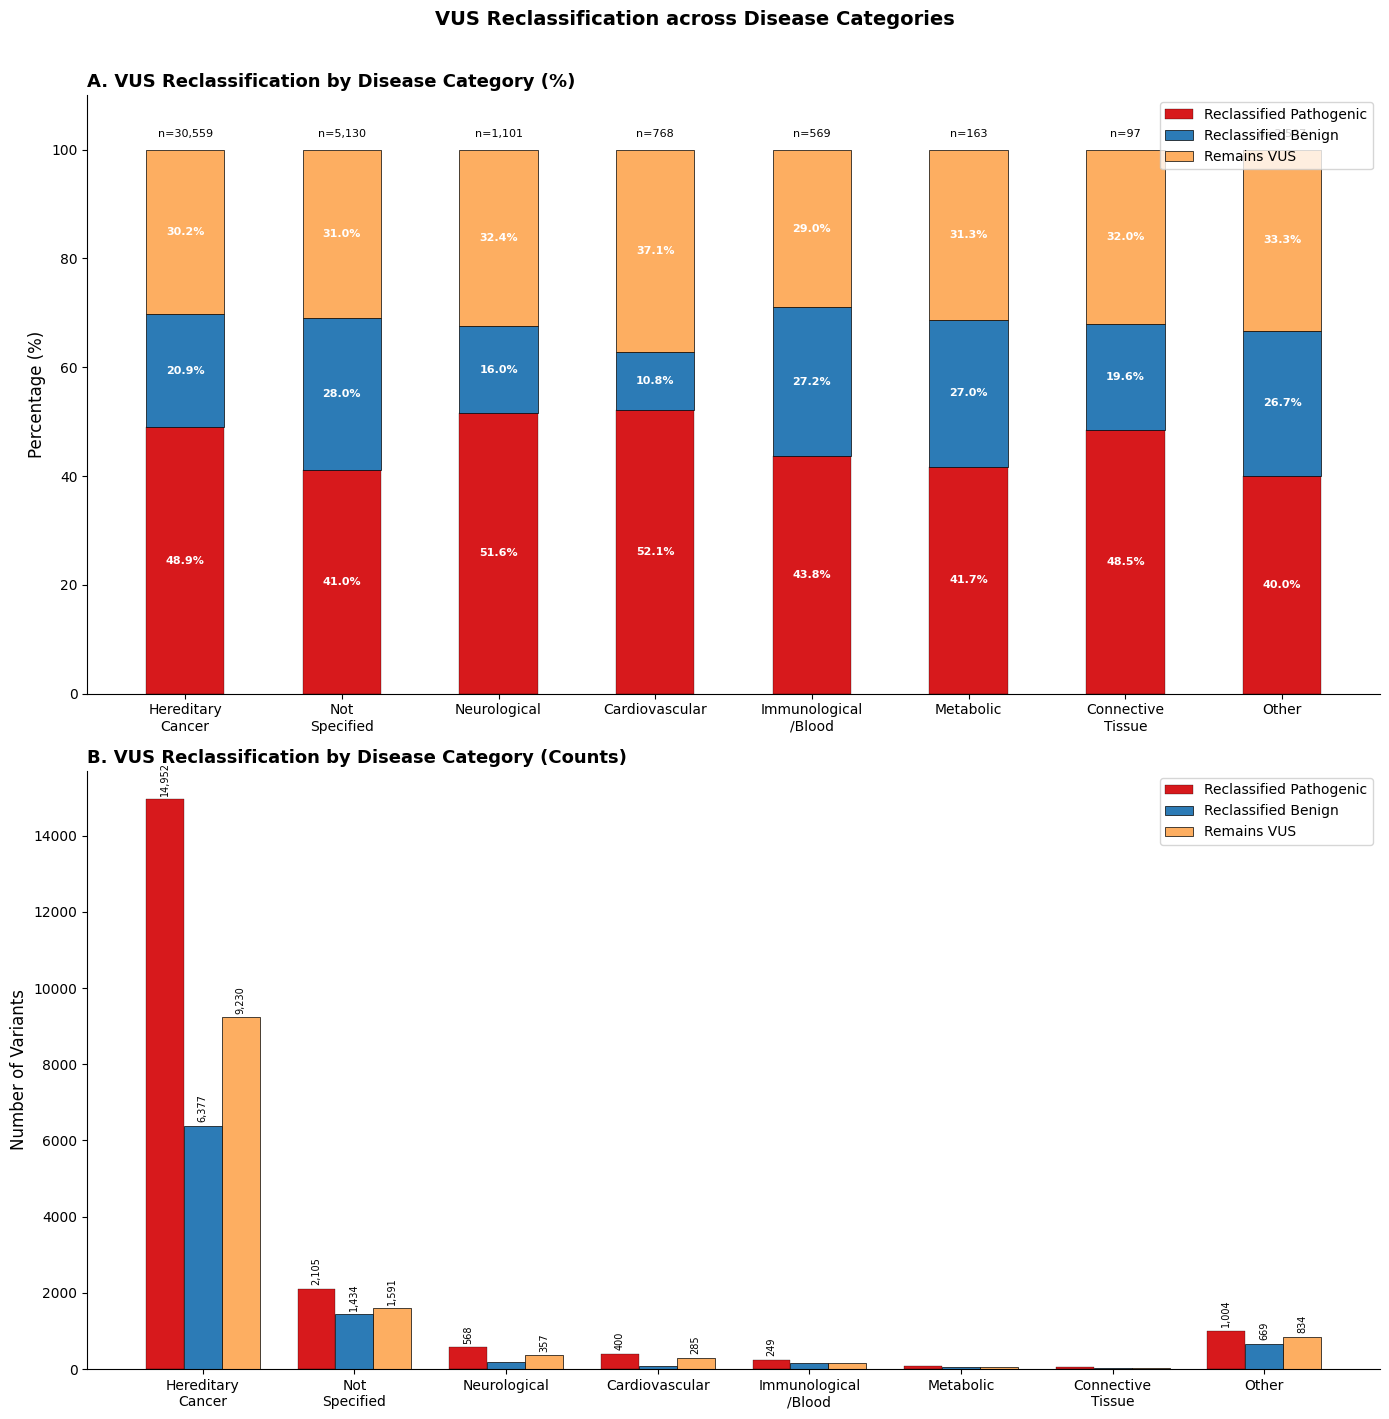

Saved: figure_disease_categories.png


In [25]:
categories   = ['Hereditary\nCancer', 'Not\nSpecified', 'Neurological',
                'Cardiovascular', 'Immunological\n/Blood', 'Metabolic',
                'Connective\nTissue', 'Other']
n_pathogenic = [14952, 2105, 568, 400, 249, 68, 47, 1004]
n_benign_dc  = [6377,  1434, 176,  83, 155, 44, 19,  669]
n_remains_dc = [9230,  1591, 357, 285, 165, 51, 31,  834]
totals       = [p+b+r for p,b,r in zip(n_pathogenic, n_benign_dc, n_remains_dc)]

patho_pct  = [p/t*100 for p,t in zip(n_pathogenic, totals)]
benign_pct = [b/t*100 for b,t in zip(n_benign_dc,  totals)]
rem_pct    = [r/t*100 for r,t in zip(n_remains_dc, totals)]
x = range(len(categories))
w = 0.25

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Panel A — stacked %
axes[0].bar(x, patho_pct, 0.5, label='Reclassified Pathogenic',
            color='#D7191C', edgecolor='black', linewidth=0.2)
axes[0].bar(x, benign_pct, 0.5, bottom=patho_pct,
            label='Reclassified Benign', color='#2C7BB6', edgecolor='black', linewidth=0.5)
axes[0].bar(x, rem_pct, 0.5,
            bottom=[p+b for p,b in zip(patho_pct, benign_pct)],
            label='Remains VUS', color='#FDAE61', edgecolor='black', linewidth=0.5)
for i, (p, b, r) in enumerate(zip(patho_pct, benign_pct, rem_pct)):
    if p > 5: axes[0].text(i, p/2,       f'{p:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    if b > 5: axes[0].text(i, p + b/2,   f'{b:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    if r > 5: axes[0].text(i, p + b + r/2, f'{r:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    axes[0].text(i, 102, f'n={totals[i]:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(categories, fontsize=10)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_title('A. VUS Reclassification by Disease Category (%)',
                  fontsize=13, fontweight='bold', loc='left')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].set_ylim(0, 110)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Panel B — absolute counts
xarr = list(x)
bp = axes[1].bar([i - w for i in xarr], n_pathogenic, w,
                 label='Reclassified Pathogenic', color='#D7191C', edgecolor='black', linewidth=0.2)
bb = axes[1].bar(xarr,               n_benign_dc,  w,
                 label='Reclassified Benign',     color='#2C7BB6', edgecolor='black', linewidth=0.5)
br = axes[1].bar([i + w for i in xarr], n_remains_dc, w,
                 label='Remains VUS',             color='#FDAE61', edgecolor='black', linewidth=0.5)
for bars in [bp, bb, br]:
    for bar in bars:
        h = bar.get_height()
        if h > 200:
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 100,
                         f'{int(h):,}', ha='center', va='bottom', fontsize=7, rotation=90)
axes[1].set_xticks(xarr); axes[1].set_xticklabels(categories, fontsize=10)
axes[1].set_ylabel('Number of Variants', fontsize=12)
axes[1].set_title('B. VUS Reclassification by Disease Category (Counts)',
                  fontsize=13, fontweight='bold', loc='left')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('VUS Reclassification across Disease Categories',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure_disease_categories.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_disease_categories.png')

## 8. Export Results

In [26]:
vus_output = vus_df[[
    'Chrom', 'Pos', 'ID', 'Ref', 'Alt',
    'Consequence', 'IMPACT', 'Gene', 'SYMBOL',
    'BIOTYPE', 'Germline classification',
    'rf_prob', 'predicted_class',
    'PHRED', 'MAX_AF', 'PolyPhen_score'
]].copy()

vus_output.to_csv('vus_reclassification_results.csv', index=False)
print(f'Saved: vus_reclassification_results.csv')
print(f'Shape: {vus_output.shape}')
print(f'\nPredicted class breakdown:')
print(vus_output['predicted_class'].value_counts())

Saved: vus_reclassification_results.csv
Shape: (40894, 16)

Predicted class breakdown:
predicted_class
Reclassified_Pathogenic    19393
Remains_VUS                12544
Reclassified_Benign         8957
Name: count, dtype: int64
